Subir los ficheros del INE
- Actividad_Evolucion_2014-2023
- Dotacion_Evolucion_2014-2023

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Actividad_Evolucion_2014-2023.xlsx to Actividad_Evolucion_2014-2023.xlsx
Saving Dotacion_Evolucion_2014-2023.xlsx to Dotacion_Evolucion_2014-2023.xlsx


Configuración

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR = "."             # los ficheros subidos quedan en el directorio actual de Colab
OUT_DIR = "./eda_assets"
os.makedirs(OUT_DIR, exist_ok=True)

AÑOS = list(range(2014, 2024))
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

Función auxiliar (localizar la fila TOTAL de una tabla

In [3]:
def extraer_fila_total(path_excel, hoja, texto_fila, skip_hasta=None):
    df = pd.read_excel(path_excel, sheet_name=hoja, header=None)
    fila_anios = None
    for i, row in df.iterrows():
        vals = row.tolist()
        if 2014 in vals and 2023 in vals:
            fila_anios = i
            col_2014 = vals.index(2014)
            break
    if fila_anios is None:
        raise ValueError(f"No se encontró la fila de años en la hoja {hoja}")

    inicio = skip_hasta if skip_hasta is not None else fila_anios
    for i in range(inicio, len(df)):
        celda = df.iloc[i, 1]
        if isinstance(celda, str) and texto_fila.lower() in celda.lower():
            valores = df.iloc[i, col_2014:col_2014 + 10].tolist()
            return pd.Series(valores, index=AÑOS, name=texto_fila)
    raise ValueError(f"No se encontró la fila '{texto_fila}' en la hoja {hoja}")

Extracción de series

In [4]:
actividad_path = f"{DATA_DIR}/Actividad_Evolucion_2014-2023.xlsx"

altas_total = extraer_fila_total(actividad_path, "TABLA 3.1 3.2", "TOTAL")
estancia_media_total = extraer_fila_total(actividad_path, "TABLA 3.4 3.5", "TOTAL")
ocupacion_total = extraer_fila_total(actividad_path, "TABLA 3.4 3.5", "TOTAL", skip_hasta=15)
urgencias_total = extraer_fila_total(actividad_path, "TABLA 3.15-16", "TOTAL")

Extracción de series - camas (dotación evolución)

In [5]:
dotacion_path = f"{DATA_DIR}/Dotacion_Evolucion_2014-2023.xlsx"

camas_publicas = extraer_fila_total(dotacion_path, "TABLA 1.5 1.6", "Públicos-SNS")
camas_privadas = extraer_fila_total(dotacion_path, "TABLA 1.5 1.6", "Privados")
camas_total = camas_publicas + camas_privadas

Gráfico de altas hospitalarias totales

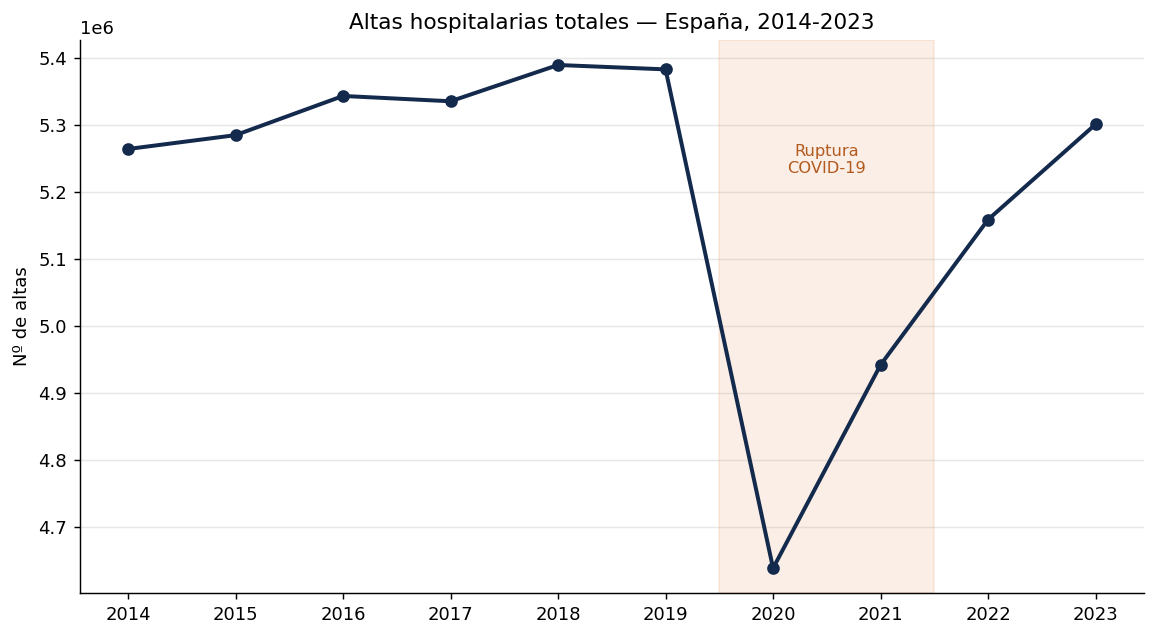

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(AÑOS, altas_total.values, marker="o", color="#132a4c", linewidth=2.2)
ax.axvspan(2019.5, 2021.5, color="#e07b39", alpha=0.12)
ax.text(2020.5, altas_total.max() * 0.97, "Ruptura\nCOVID-19", ha="center",
        fontsize=9, color="#b25b1e")
ax.set_title("Altas hospitalarias totales — España, 2014-2023")
ax.set_ylabel("Nº de altas")
ax.set_xticks(AÑOS)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/eda_altas_totales.png")
plt.show()

Gráfico estancia media y ocupación

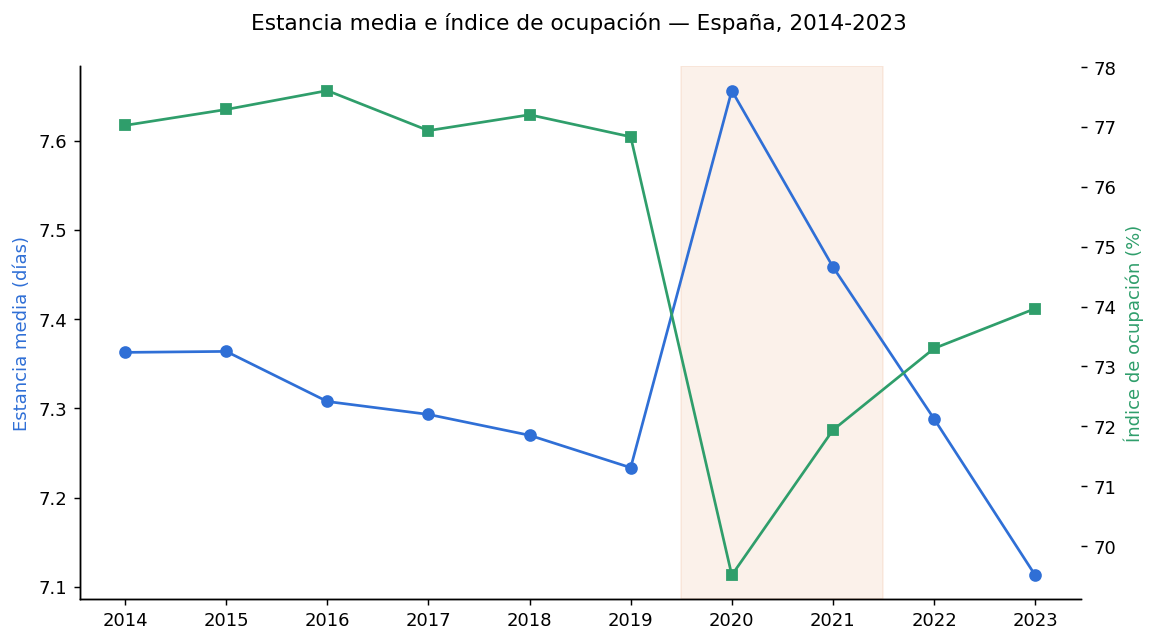

In [7]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(AÑOS, estancia_media_total.values, marker="o", color="#2f6fd6", label="Estancia media (días)")
ax1.set_ylabel("Estancia media (días)", color="#2f6fd6")
ax1.set_xticks(AÑOS)
ax2 = ax1.twinx()
ax2.plot(AÑOS, ocupacion_total.values * 100, marker="s", color="#2f9e6b", label="Índice de ocupación (%)")
ax2.set_ylabel("Índice de ocupación (%)", color="#2f9e6b")
ax1.axvspan(2019.5, 2021.5, color="#e07b39", alpha=0.10)
fig.suptitle("Estancia media e índice de ocupación — España, 2014-2023")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/eda_estancia_ocupacion.png")
plt.show()

Gráfico de camas en funcionamiento (pública vs privada)

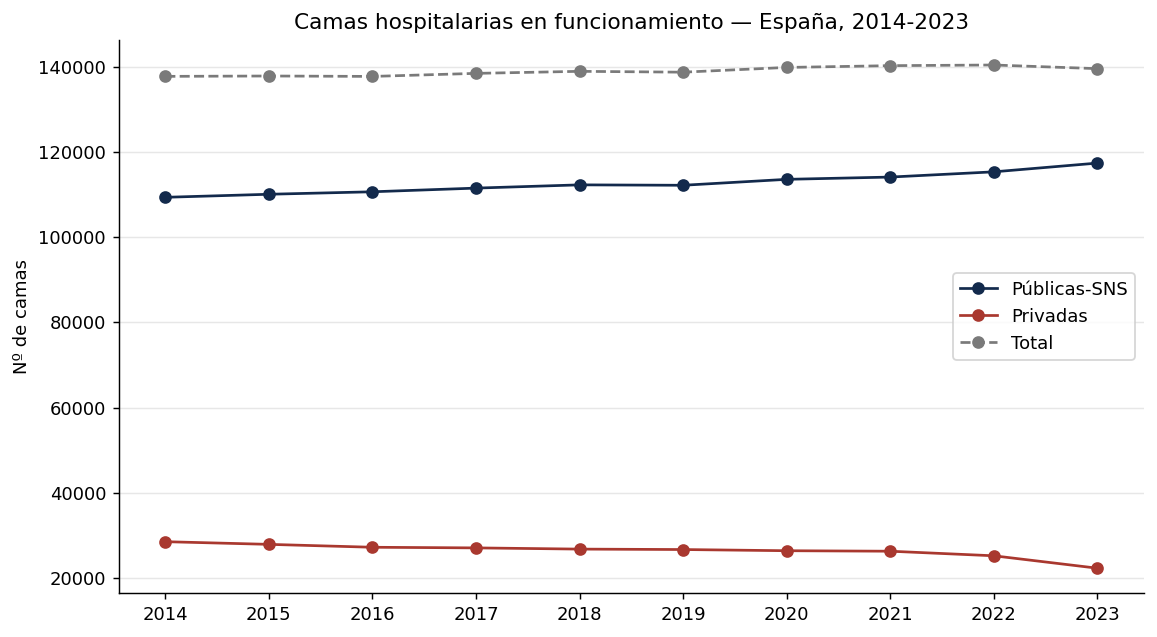

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(AÑOS, camas_publicas.values, marker="o", color="#132a4c", label="Públicas-SNS")
ax.plot(AÑOS, camas_privadas.values, marker="o", color="#a9382f", label="Privadas")
ax.plot(AÑOS, camas_total.values, marker="o", color="#7a7a7a", linestyle="--", label="Total")
ax.set_title("Camas hospitalarias en funcionamiento — España, 2014-2023")
ax.set_ylabel("Nº de camas")
ax.set_xticks(AÑOS)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/eda_camas.png")
plt.show()

Gráfico urgencias atendidas

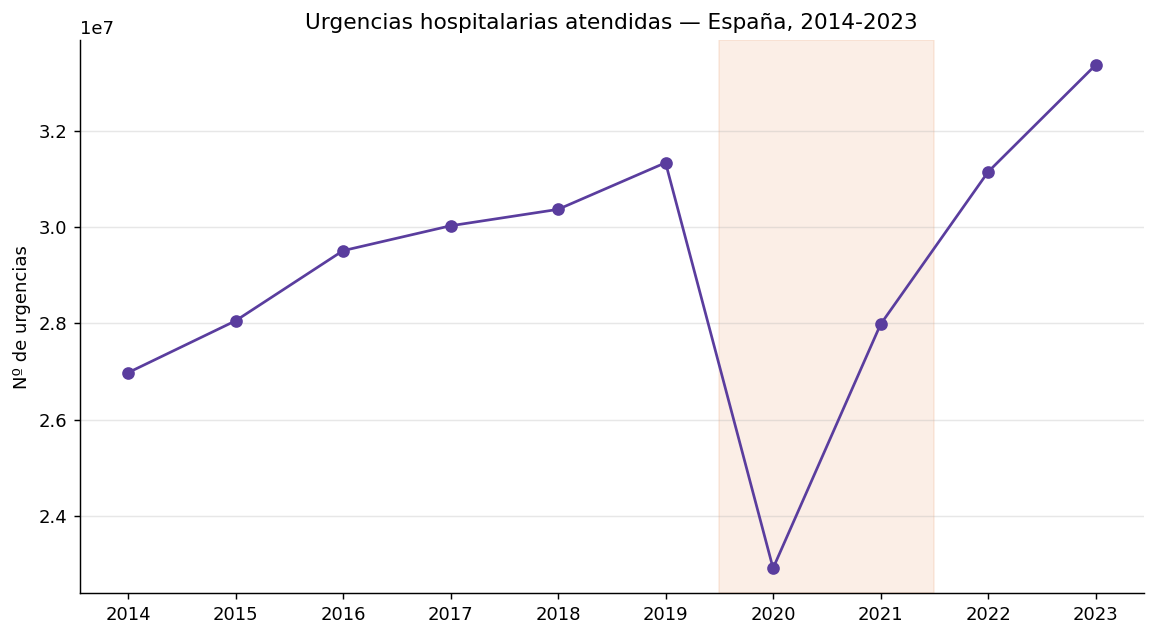

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(AÑOS, urgencias_total.values, marker="o", color="#5a3d9e")
ax.axvspan(2019.5, 2021.5, color="#e07b39", alpha=0.12)
ax.set_title("Urgencias hospitalarias atendidas — España, 2014-2023")
ax.set_ylabel("Nº de urgencias")
ax.set_xticks(AÑOS)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/eda_urgencias.png")
plt.show()

Resumen de variaciones clave + CSV

In [10]:
resumen = pd.DataFrame({
    "altas_totales": altas_total,
    "estancia_media": estancia_media_total,
    "ocupacion_pct": ocupacion_total * 100,
    "urgencias": urgencias_total,
    "camas_publicas": camas_publicas,
    "camas_privadas": camas_privadas,
    "camas_total": camas_total,
})
resumen.index.name = "año"
resumen.to_csv(f"{OUT_DIR}/resumen_serie_nacional_2014_2023.csv")

def variacion(serie, a, b):
    return round((serie[b] - serie[a]) / serie[a] * 100, 2)

print("Altas totales 2019->2020:", variacion(altas_total, 2019, 2020), "%")
print("Altas totales 2020->2023:", variacion(altas_total, 2020, 2023), "%")
print("Altas totales 2019->2023:", variacion(altas_total, 2019, 2023), "%")
print("Urgencias 2019->2020:", variacion(urgencias_total, 2019, 2020), "%")
print("Urgencias 2019->2023:", variacion(urgencias_total, 2019, 2023), "%")
print("Camas públicas 2014->2023:", variacion(camas_publicas, 2014, 2023), "%")
print("Camas privadas 2014->2023:", variacion(camas_privadas, 2014, 2023), "%")
print("Camas total 2014->2023:", variacion(camas_total, 2014, 2023), "%")

resumen  # muestra la tabla resumen en Colab

Altas totales 2019->2020: -13.83 %
Altas totales 2020->2023: 14.29 %
Altas totales 2019->2023: -1.52 %
Urgencias 2019->2020: -26.91 %
Urgencias 2019->2023: 6.49 %
Camas públicas 2014->2023: 7.35 %
Camas privadas 2014->2023: -21.92 %
Camas total 2014->2023: 1.31 %


,altas_totales,estancia_media,ocupacion_pct,urgencias,camas_publicas,camas_privadas,camas_total
año,,,,,,,
2014,5264867.0,7.362638,77.025787,26973994.0,109435.0,28442.0,137877.0
2015,5285563.0,7.363735,77.291326,28053453.0,110150.0,27814.0,137964.0
2016,5344086.0,7.307606,77.606580,29512722.0,110734.0,27132.0,137866.0
2017,5336131.0,7.293127,76.938498,30030788.0,111598.0,26983.0,138581.0
2018,5390303.0,7.269756,77.203116,30372325.0,112362.0,26699.0,139061.0
2019,5383760.0,7.233480,76.835132,31342724.0,112264.0,26597.0,138861.0
2020,4639007.0,7.655988,69.514716,22907100.0,113660.0,26317.0,139977.0
2021,4942588.0,7.458487,71.937349,27980842.0,114195.0,26202.0,140397.0
2022,5159517.0,7.288269,73.300450,31152076.0,115425.0,25126.0,140551.0


In [11]:
# ------------------------------------------------------------------
# CELDA 11 (opcional) — Descargar los gráficos y el CSV a tu ordenador
# ------------------------------------------------------------------
import shutil
shutil.make_archive("eda_assets", "zip", OUT_DIR)
files.download("eda_assets.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>